# **MÓDULO 15 - Exercício**
# Análise  - A segunda etapa da Pré Modelagem

# 1) O primeiro exercício é o de salvar a base que criaram na atividade do módulo anterior em csv e abrir ela neste arquivo.
Igual fizemos no início do módulo atual no início da primeira aula.

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import plotly.express as px

In [ ]:
df = pd.read_csv("/content/arquivo_editado.csv")
df.head(10)

,customerID,gender,senior_citizen,married,dependents,tenure_months,phone_service,internet_service,security_service,technical_support,streaming_tv,contract_type,payment_method,monthly_payment,total_paid,churn
0,7590-VHVEG,female,0,yes,no,1,no,dsl,no,no,no,month-to-month,electronic check,29.85,29.85,no
1,5575-GNVDE,male,0,no,no,34,yes,dsl,yes,no,no,one year,mailed check,56.95,1889.50,no
2,3668-QPYBK,male,0,no,no,2,yes,dsl,yes,no,no,month-to-month,mailed check,53.85,108.15,yes
3,7795-CFOCW,male,0,no,no,45,no,dsl,yes,yes,no,one year,bank transfer (automatic),70.55,1840.75,no
4,8191-XWSZG,female,0,no,no,52,yes,no,no internet service,no internet service,no internet service,one year,mailed check,70.55,1022.95,no
5,9959-WOFKT,male,0,no,yes,71,yes,fiber optic,yes,no,yes,two year,bank transfer (automatic),70.55,7382.25,no
6,4190-MFLUW,female,0,yes,yes,10,yes,dsl,no,yes,no,month-to-month,credit card (automatic),70.55,528.35,yes
7,4183-MYFRB,female,0,no,no,21,yes,fiber optic,no,no,no,month-to-month,electronic check,70.55,1862.90,no
8,8779-QRDMV,male,1,no,no,1,no,dsl,no,no,no,month-to-month,electronic check,70.55,39.65,yes
9,1680-VDCWW,male,0,yes,no,12,yes,no,no internet service,no internet service,no internet service,one year,bank transfer (automatic),70.55,202.25,no


# 2) Comece pela análise univariada:

A) Utilize a função describe no seu dataframe, veja os insights que consegue retirar.

B) Já é possível identificar variáveis com possíveis outliers? Se sim, quais?

C) Plot gráficos que considerar importante para completar sua análise univariada. (Lembrando que sua variável preditora é o churn). Não se esqueça de trazer insights de cada gráfico plotado. Utilize pelo menos 4 variáveis distintas.

D) Verifique se os dados das variáveis Booleanas são balanceados ou não.

In [ ]:
df.describe()

,senior_citizen,tenure_months,monthly_payment,total_paid
count,1006.000000,1006.000000,1006.000000,1006.000000
mean,0.157058,32.861829,65.627187,2310.174652
std,0.364036,24.862924,27.895187,2311.330522
min,0.000000,1.000000,18.800000,18.800000
25%,0.000000,8.000000,45.225000,384.887500
50%,0.000000,30.000000,70.550000,1390.875000
75%,0.000000,56.000000,86.250000,3891.625000
max,1.000000,72.000000,118.650000,8564.750000


# Insights
- A base tem predominância de clientes não idosos;
- Existem clientes muitos novos (1 mês e clientes muito antigo (72 meses)
- A mediana é maior que a média, nos pagamentos mensais, indicando grande variação nos valores.
- A média de total pago é maior que a mediana, sugerindo clientes com pagamentos acumulados altos.

# Possíveis Outliers
- monthly_payment
- total_paid

# Análises univariadas

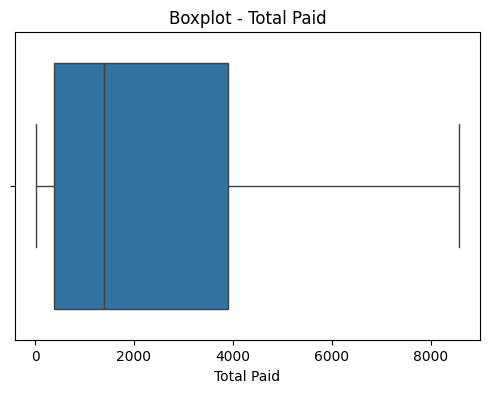

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['total_paid'])

plt.title("Boxplot - Total Paid")
plt.xlabel("Total Paid")

plt.show()

O boxplot indica que a variável total_paid apresenta alta dispersão. A mediana está aproximadamente em 1400, enquanto o terceiro quartil está próximo de 3900, mostrando que uma parcela dos clientes possui valores acumulados significativamente maiores.

Observa-se também uma cauda longa à direita, chegando a valores próximos de 8500, o que indica uma distribuição assimétrica positiva. Isso sugere que existem clientes que acumularam valores totais muito altos, provavelmente devido a maior tempo de permanência ou planos mais caros.

Apesar da grande amplitude dos dados, não aparecem outliers explícitos no gráfico, indicando que esses valores elevados ainda estão dentro do limite esperado da distribuição.

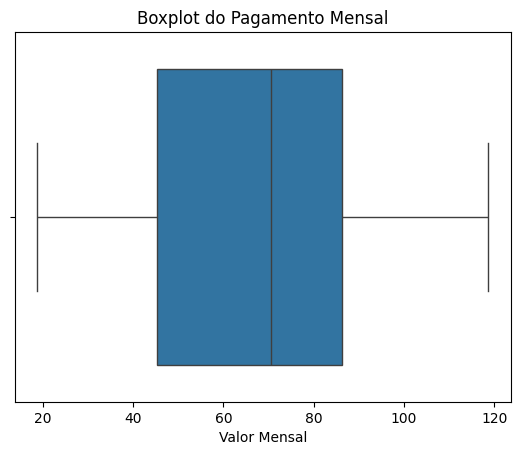

In [ ]:
sns.boxplot(x=df['monthly_payment'])
plt.title("Boxplot do Pagamento Mensal")
plt.xlabel("Valor Mensal")
plt.show()

O boxplot mostra que os pagamentos mensais possuem dispersão moderada, com a mediana em torno de 70. A maior parte dos valores está concentrada aproximadamente entre 45 e 86, indicando que essa é a faixa de pagamento mais comum entre os clientes.

Os valores mínimo e máximo variam aproximadamente entre 18 e 118, mostrando que existem diferentes níveis de planos ou serviços oferecidos.

Assim como no gráfico anterior, não são observados outliers evidentes, sugerindo que os valores de pagamento mensal estão relativamente bem distribuídos dentro do intervalo esperado.

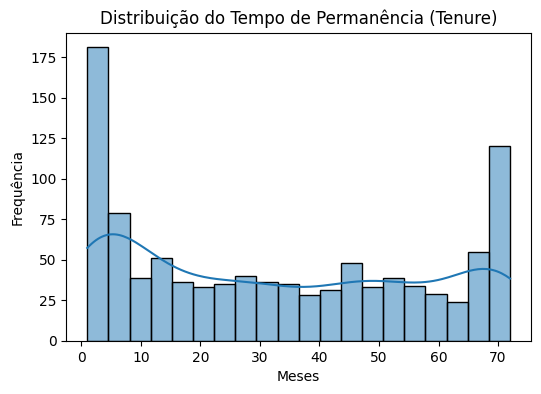

In [ ]:

plt.figure(figsize=(6,4))

sns.histplot(df['tenure_months'], bins=20, kde=True)

plt.title("Distribuição do Tempo de Permanência (Tenure)")
plt.xlabel("Meses")
plt.ylabel("Frequência")

plt.show()

O histograma mostra a distribuição do tempo de permanência dos clientes na empresa. Observa-se uma concentração maior de clientes nos primeiros meses de contrato, indicando que uma parcela significativa da base é composta por clientes relativamente novos.

Também é possível notar outra concentração próxima ao limite máximo de 72 meses, sugerindo a presença de clientes com relacionamento de longo prazo com a empresa.

A distribuição parece apresentar duas regiões de maior frequência, o que pode indicar perfis distintos de clientes: aqueles que estão iniciando o relacionamento com a empresa e aqueles que permanecem por longos períodos

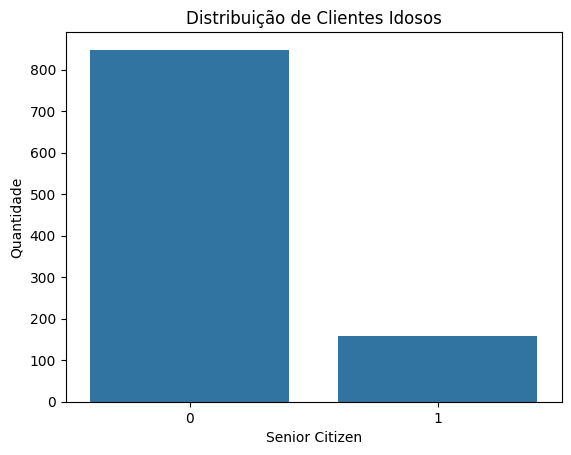

In [ ]:
sns.countplot(x=df['senior_citizen'])
plt.title("Distribuição de Clientes Idosos")
plt.xlabel("Senior Citizen")
plt.ylabel("Quantidade")
plt.show()

O gráfico mostra a distribuição dos clientes entre idosos (1) e não idosos (0).

Observa-se que a grande maioria dos clientes não pertence ao grupo de idosos, enquanto apenas uma pequena parcela da base é composta por clientes idosos.

Isso indica que a variável não está balanceada, com predominância significativa de clientes não idosos na base de dados.

Essa informação é importante para análises futuras, pois diferentes grupos demográficos podem apresentar comportamentos distintos em relação ao cancelamento de serviços (churn).

# 3) Identifique e trate as colunas que contém outliers.
Caso opte por mante-los ou altera-los justifique sua escolha.


In [ ]:
# Função para detectar outliers usando IQR
def detectar_outliers(coluna):

    Q1 = df[coluna].quantile(0.25)
    Q3 = df[coluna].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers = df[(df[coluna] < limite_inferior) | (df[coluna] > limite_superior)]

    print(f"{coluna}: {len(outliers)} outliers encontrados")

detectar_outliers('monthly_payment')
detectar_outliers('total_paid')

monthly_payment: 0 outliers encontrados
total_paid: 0 outliers encontrados


Neste caso, optei por manter os outliers.Esses valores não parecem ser erros de medição, mas sim clientes reais com valores maiores de pagamento ou maior tempo de relacionamento. Remover esses dados poderia causar: a) perda de informação importante; b) distorção da distribuição real dos clientes.

- Além disso, em problemas de churn, clientes com valores mais altos podem ser muito relevantes para o modelo preditivo.

# 4) Realize a etapa da análise bivariada:
A) Questione pelo menos 5 informações e traga as respostas utilizando visuais gráficos e insights.


B) Quais variáveis você acredita serem as mais importantes para esse projetos relacionadas a variável Churn?

## Clientes com maior tempo de permanência cancelam menos?

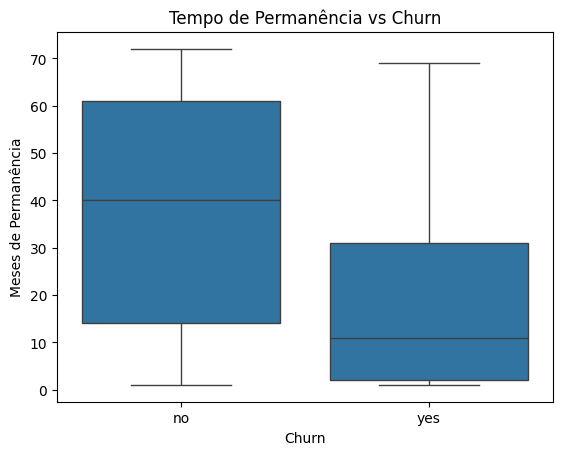

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='churn', y='tenure_months', data=df)

plt.title("Tempo de Permanência vs Churn")
plt.xlabel("Churn")
plt.ylabel("Meses de Permanência")

plt.show()

O boxplot mostra que clientes que não cancelaram (churn = no) possuem uma mediana de tempo de permanência significativamente maior, aproximadamente em torno de 40 meses.

- Já os clientes que cancelaram (churn = yes) apresentam uma mediana muito menor, próxima de 10 meses.

## Clientes que pagam mais mensalmente cancelam mais?

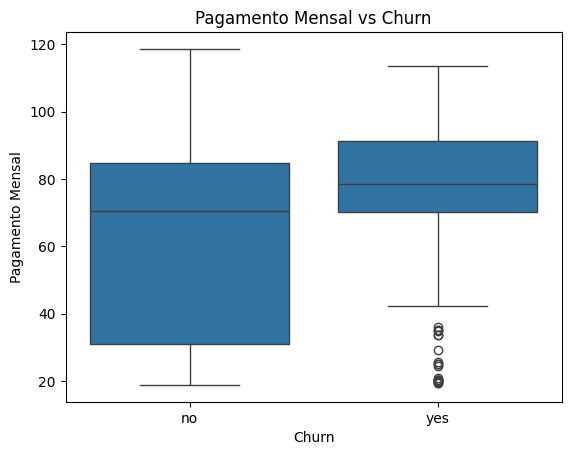

In [ ]:
sns.boxplot(x='churn', y='monthly_payment', data=df)

plt.title("Pagamento Mensal vs Churn")
plt.xlabel("Churn")
plt.ylabel("Pagamento Mensal")

plt.show()

O boxplot indica que clientes que cancelaram (churn = yes) possuem pagamento mensal mediano ligeiramente maior do que aqueles que permaneceram.

- Além disso, observa-se uma concentração maior de valores mensais entre 70 e 90 para clientes que cancelaram.

## Clientes idosos apresentam maior churn?

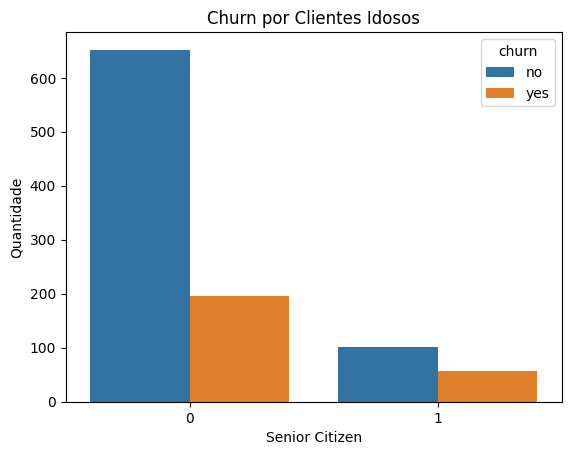

In [ ]:
sns.countplot(x='senior_citizen', hue='churn', data=df)

plt.title("Churn por Clientes Idosos")
plt.xlabel("Senior Citizen")
plt.ylabel("Quantidade")

plt.show()

O gráfico mostra que a maioria dos clientes não é idosa, porém proporcionalmente observa-se que clientes idosos apresentam uma taxa de churn relativamente maior quando comparados aos não idosos.

- Mesmo sendo um grupo menor na base de dados, a quantidade de cancelamentos dentro desse grupo é significativa.

## Clientes com maior valor total pago cancelam menos?

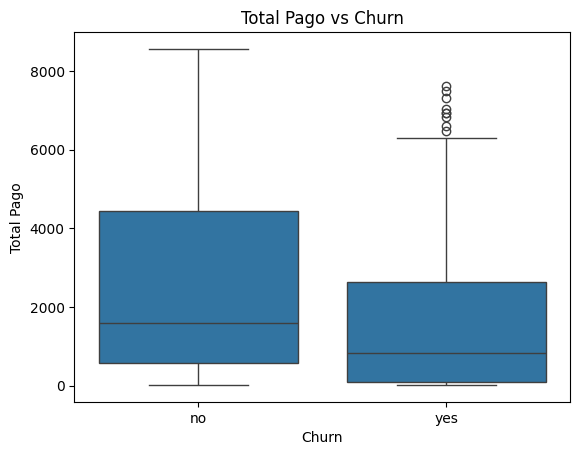

In [ ]:
sns.boxplot(x='churn', y='total_paid', data=df)

plt.title("Total Pago vs Churn")
plt.xlabel("Churn")
plt.ylabel("Total Pago")

plt.show()

O boxplot mostra que clientes que não cancelaram possuem valores totais pagos significativamente maiores.

- Isso ocorre porque esses clientes normalmente possuem maior tempo de permanência na empresa, acumulando mais pagamentos ao longo do tempo.

- Clientes que cancelaram apresentam valores totais pagos consideravelmente menores, indicando que o cancelamento geralmente ocorre nos primeiros meses de contrato.

## Existe relação geral entre as variáveis numéricas?

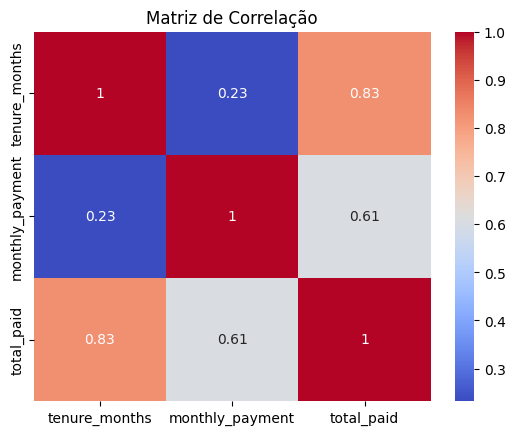

In [ ]:
corr = df[['tenure_months','monthly_payment','total_paid']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Matriz de Correlação")

plt.show()

A matriz de correlação apresenta o grau de relação entre as variáveis numéricas tenure_months, monthly_payment e total_paid. Observa-se que a correlação mais forte ocorre entre tenure_months e total_paid, indicando que clientes que permanecem mais tempo na empresa tendem a acumular valores totais pagos maiores. A relação entre monthly_payment e total_paid também é positiva, porém moderada, enquanto a correlação entre tenure_months e monthly_payment é relativamente fraca, sugerindo pouca relação direta entre o tempo de permanência e o valor pago mensalmente.
- Clientes que permanecem mais tempo na empresa acumulam valores totais pagos maiores, indicando uma forte relação entre fidelização e valor total gerado pelo cliente.

- O valor mensal pago não depende diretamente do tempo de permanência, o que sugere que clientes com diferentes tempos de contrato podem estar associados a diferentes planos ou serviços.